# ARoF RVTDNN-DPD - Hyperparameters optimization with Optuna

In [1]:
import sys

project_path = r"C:\Users\PC\Documents\Mestrado\DPD"
file_path    = project_path + r"\Optuna_studies\DPD_RVTDNN"

sys.path.append(project_path)
sys.path.append(file_path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch as th
import optuna

from torch                    import nn
from scipy.signal             import welch, firwin, hilbert
from scipy.constants          import pi
from tqdm.notebook            import tqdm
from tabulate                 import tabulate
from functools                import partial

from optic.comm.ofdm          import modulateOFDM, demodulateOFDM
from optic.comm.modulation    import modulateGray
from optic.models.channels    import linearFiberChannel
from optic.models.devices     import mzm, photodiode
from optic.comm.metrics       import fastBERcalc, calcEVM
from optic.dsp.core           import pnorm, signal_power, upsample, pulseShape, decimate, finddelay
from optic.dsp.coreGPU        import firFilter
from optic.utils              import parameters, dBm2W
from optic_private.dsp.core   import calcACLR
from optic_private.torchUtils import fitFilterNN

from dpd.nn                   import NN_training
from dpd.utils                import power_amplifier
from dpd.plots                import calc_per_carrier
from dpd.optuna_tasks         import objective_dpd, get_pareto

from optuna.trial             import TrialState
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
font = {'size':14}
plt.rc('font', **font)
plt.rcParams["font.family"] = "serif"

### 1 - Geração do Sinal OFDM

In [4]:
device = "cuda"
includeMemory = True

# Parâmetros de modulação
Rb = 5e9                               # Taxa de transmissão de bits
SpS = 32                               # Amostras por símbolo

# Parâmetros OFDM
paramOFDM = parameters()
paramOFDM.modOrder = 64                # Ordem da modulação
paramOFDM.modType  = 'qam'             # Tipo de modulação
paramOFDM.Nfft = 1024                  # Tam. da FFT
paramOFDM.G    = 32                   # Tam. do prefixo cíclico
paramOFDM.hermitSymmetry = False
paramOFDM.SpS = SpS

if paramOFDM.hermitSymmetry:
    Ns = paramOFDM.Nfft//2 - 1
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([], dtype = np.int64)
else:
    Ns = paramOFDM.Nfft
    paramOFDM.pilotCarriers = np.linspace(0, Ns - 1, 8, dtype = np.int64)
    paramOFDM.nullCarriers  = np.array([paramOFDM.Nfft//2], dtype = np.int64)

# Núm. de subportadoras de informação
Np = paramOFDM.pilotCarriers.size
Nz = paramOFDM.nullCarriers.size
Ni = Ns - Np - Nz
paramOFDM.Ni = Ni

Rs = Rb / ( Ni/(paramOFDM.Nfft + paramOFDM.G) * np.log2(paramOFDM.modOrder) )    # Taxa de transmissão de símbolos
Fs  = Rs * SpS                                                          # Taxa de amostragem

# Geração dos bits e dos símbolos QAM
numOFDMframes = 50
np.random.seed(2)
bits = np.random.randint(2, size = (numOFDMframes*Ni, int(np.log2(paramOFDM.modOrder))))

symbTx = modulateGray(bits, paramOFDM.modOrder, paramOFDM.modType)
symbTx = pnorm(symbTx)

pilotSymb = 0.25*(max(symbTx.real) + 1j*max(symbTx.imag))
paramOFDM.pilot = pilotSymb

In [5]:
sigTx = modulateOFDM(symbTx, paramOFDM)
sigTx = pnorm(sigTx)

t = np.arange(0, len(sigTx))*1/Fs
t_CP   = SpS * paramOFDM.G * (1/Fs)
t_symb = SpS * (paramOFDM.Nfft + paramOFDM.G) * (1/Fs)

In [6]:
table = [['Grandeza', 'Parâmetro', 'Valor'],
         ['Taxa de amostragem', 'Fs', f'{Fs*1e-9:.2f} Gsamples/s'],
         ['Taxa de símbolos', 'Rs', f'{Rs*1e-9:.2f} Gsymb/s'],
         ['Taxa de transmissão', 'Rb', f'{Rb*1e-9:.2f} Gb/s'],
         ['Ordem da constelação', 'M', f'{paramOFDM.modOrder}'],
         ['Tamanho da FFT', 'Nfft', f'{paramOFDM.Nfft}'],
         ['Tamanho do prefixo cíclico', 'G', f'{paramOFDM.G}'],
         ['Num. port. de informação', 'Ns', f'{Ni}'],
         ['Num. port. piloto', 'Np', f'{Np}'],
         ['Num. port. nulas', 'Nz', f'{Nz}'],
         ['Espaçamento entre subportadoras', 'Delta_f', f'{(Rs/paramOFDM.Nfft)*1e-6:.2f} MHz'],
         ['Duração do símbolo OFDM', 'T_symb', f'{1e9*t_symb:.2f} ns'],
         ['Duração do prefixo cíclico', 'T_CP', f'{1e9*t_CP:.2f} ns'] ]

print(tabulate(table, headers = 'firstrow', tablefmt = 'fancy_grid'))

╒═════════════════════════════════╤═════════════╤══════════════════╕
│ Grandeza                        │ Parâmetro   │ Valor            │
╞═════════════════════════════════╪═════════════╪══════════════════╡
│ Taxa de amostragem              │ Fs          │ 27.74 Gsamples/s │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de símbolos                │ Rs          │ 0.87 Gsymb/s     │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Taxa de transmissão             │ Rb          │ 5.00 Gb/s        │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Ordem da constelação            │ M           │ 64               │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho da FFT                  │ Nfft        │ 1024             │
├─────────────────────────────────┼─────────────┼──────────────────┤
│ Tamanho do prefixo cíclico      │ G           │ 32               │
├─────────────────────────────────

In [7]:
## Parametrização dos dispositivos

# Parâmetros do MZM
paramMZM = parameters()
paramMZM.Vpi = 3
paramMZM.Vb = -paramMZM.Vpi/2
paramMZM.Pin_OF = 10

# Parâmetros do canal óptico
paramChannel = parameters()
paramChannel.L = 25
paramChannel.alpha = 0.2
paramChannel.D = 16
paramChannel.Fc = 193.1e12
paramChannel.Fs = Fs

#
paramRF = parameters()
paramRF.fc_e = 7.5e9
paramRF.Pin_RF = 17
paramRF.Pin_PA = 5

# Parâmetros do fotodiodo
paramPD = parameters()
paramPD.ideal = False
paramPD.B = paramRF.fc_e + 2*Rs
paramPD.Ipd_sat = 50e-3
paramPD.Fs = Fs

### 2 Canal RoF

In [8]:
# Sinal RF
sigTx_RF = np.real( sigTx * np.exp(1j*2*pi*paramRF.fc_e*t) )

gain_pre_MZM = 10**( np.log10(dBm2W(paramRF.Pin_RF)/signal_power(sigTx_RF))/2)
sigTx_RF *= gain_pre_MZM
sigTx_RF = np.clip(sigTx_RF, -paramMZM.Vpi/2, paramMZM.Vpi/2)

# Sinal óptico
Ai     = np.sqrt(dBm2W(paramMZM.Pin_OF))*np.ones(sigTx_RF.size)
sigTxo = mzm(Ai, sigTx_RF, paramMZM)

numtaps = 4096
hopt_tx = firwin(numtaps, paramRF.fc_e + 2*Rs, fs = Fs)
sigTxo = np.sqrt(signal_power(sigTxo))*pnorm(firFilter(hopt_tx, sigTxo))

sigRxo = linearFiberChannel(sigTxo, paramChannel)

# Sinal elétrico (fotocorrente)
I_Rx = photodiode(sigRxo, paramPD)
I_Rx -= I_Rx.mean()

# Sinal elétrico pós-FPF
numtaps = 4096
f1 = paramRF.fc_e - 2*Rs
f2 = paramRF.fc_e + 2*Rs
hbp_RF = firwin(numtaps, (f1, f2), pass_zero = 'bandpass', fs = Fs)

I_RF = firFilter(hbp_RF, I_Rx)

# Sina elétrico pós-PA
IQ_imb = 1 # 10**(1 / 10) * np.exp(1j* 5 * pi/180)

sigRx = hilbert(I_RF)*np.exp(-1j*2*pi*paramRF.fc_e*t)
sigRx = sigRx.real + 1j*sigRx.imag * IQ_imb

gain_pre_PA = 10**( np.log10(dBm2W(paramRF.Pin_PA)/signal_power(sigRx))/2)
sigRx *= gain_pre_PA

sigRx = power_amplifier(sigRx)

sigRx_PA = sigRx.copy()
sigRx_PA = pnorm(sigRx_PA)

numtaps = 4096
hlp = firwin(numtaps, Rs/1.75, fs = Fs)
sigRx = firFilter(hlp, sigRx)

delay = finddelay(sigRx, sigTx)
sigRx = np.roll(sigRx, -delay)

rot = np.mean(sigTx/sigRx)
sigRx = rot/np.abs(rot)*sigRx

In [9]:
# Param RoF
paramRoF = parameters()
paramRoF.SpS = SpS
paramRoF.Fs  = Fs
paramRoF.Rs  = Rs
paramRoF.IQ_imb = IQ_imb
paramRoF.G_list = (gain_pre_MZM, gain_pre_PA)
paramRoF.paramMZM = paramMZM
paramRoF.paramChannel = paramChannel
paramRoF.paramRF = paramRF
paramRoF.paramPD = paramPD

### 3 Preparação do conjunto de dados de treinamento

In [10]:
SpS_nn = 4

paramDec = parameters()
paramDec.SpS_in = SpS
paramDec.SpS_out = SpS_nn

hlp = firwin(numtaps, SpS_nn*Rs/2, fs = Fs)

sigRef = decimate(pnorm(firFilter(hlp, sigTx)), paramDec).ravel()
sigIn  = decimate(pnorm(sigRx_PA), paramDec).ravel()

delay = finddelay(sigIn, sigRef)
sigIn = np.roll(sigIn, -delay)

rot = np.mean(sigRef/sigIn)
sigIn = rot/np.abs(rot)*sigIn

In [11]:
sigRef = th.from_numpy(sigRef).to(device).type(th.complex64)
sigIn  = th.from_numpy(sigIn).to(device).type(th.complex64)

### 4 - Arquitetura de Aprendizado Indireto (ILA)

In [12]:
paramILA = parameters()

paramILA.DPD = "NN"
paramILA.N = 50_000

paramILA.divByL = 1
paramILA.trainTestFrac = 0.75
paramILA.shuffle = False

paramILA.includeMemory = True
paramILA.augment = False

paramILA.device = device
paramILA.pgrsBar = False
paramILA.directLearn = False

paramILA.batch_size = 1_000
paramILA.lr = 5e-3
paramILA.epochs = 500
paramILA.activation = "relu"

paramILA.SpS_DPD = 4
paramILA.Ntaps = 4
paramILA.K = 0
paramILA.layers = [2*paramILA.Ntaps, 35, 2]
paramILA.RoF_model = None
paramILA.envelope = False

In [13]:
attr_test = parameters()
attr_test.symbTx    = symbTx
attr_test.paramRoF  = paramRoF
attr_test.paramOFDM = paramOFDM
attr_test.paramDPD  = paramILA

attr_train = parameters()
attr_train.sigIn  = sigIn
attr_train.sigRef = sigRef
attr_train.paramDPD = paramILA

In [14]:
n_trials  = 500
n_studies = np.array([3])
timeout = 60*60*15
save = True

for i, std in enumerate(n_studies):
    objective_ILA = partial(objective_dpd, attr_test = attr_test, attr_train = attr_train, metrics = ["EVM", "NFLOPs"], 
                            model_path = file_path + f"\\ILA\\Study_{std}\\Models")
    
    print(f"Study {std}:")
    study_ILA = optuna.create_study(directions=["minimize", "minimize"], sampler = optuna.samplers.TPESampler())
    study_ILA.optimize(objective_ILA, n_trials = n_trials, timeout = timeout, show_progress_bar = True)
    
    complete_trials   = study_ILA.get_trials(deepcopy = False, states = [TrialState.COMPLETE])
    n_complete_trials = len(complete_trials)
    
    study_N1      = np.zeros(n_complete_trials)
    study_N2      = np.zeros(n_complete_trials)
    study_Ntaps   = np.zeros(n_complete_trials)
    study_Nlayers = np.zeros(n_complete_trials)
    
    study_EVM    = np.zeros(n_complete_trials)
    #study_ACLR   = np.zeros(n_complete_trials)
    study_NFLOPs = np.zeros(n_complete_trials)
    
    for j in range(n_complete_trials):
        trials_params    = complete_trials[j].params
        study_EVM[j]     = complete_trials[j].values[0]
        #study_ACLR[j]    = complete_trials[j].values[1]
        study_NFLOPs[j]  = complete_trials[j].values[1]
        
        study_N1[j]      = trials_params["N1"]
        study_N2[j]      = trials_params["N2"]
        study_Ntaps[j]   = trials_params["Ntaps"]
        study_Nlayers[j] = trials_params["Nlayers"]
    
    if save:
        np.savetxt(file_path + f'\\ILA\\Study_{std}\\Parameters\\N1.txt', study_N1, fmt = '%f')
        np.savetxt(file_path + f'\\ILA\\Study_{std}\\Parameters\\N2.txt', study_N2, fmt = '%f')
        np.savetxt(file_path + f'\\ILA\\Study_{std}\\Parameters\\Ntaps.txt', study_Ntaps, fmt = '%f')
        np.savetxt(file_path + f'\\ILA\\Study_{std}\\Parameters\\Nlayers.txt', study_Nlayers, fmt = '%f')
        #np.savetxt(file_path + f'\\ILA\\Study_{std}\\Results\\ACLR.txt', study_ACLR, fmt = '%f')
        np.savetxt(file_path + f'\\ILA\\Study_{std}\\Results\\EVM.txt', study_EVM, fmt = '%f')
        np.savetxt(file_path + f'\\ILA\\Study_{std}\\Results\\NFLOps.txt', study_NFLOPs, fmt = '%f')

Study 3:


  0%|          | 0/500 [00:00<?, ?it/s]

In [15]:
study_ACLR = np.array([ np.loadtxt(file_path + f"\\ILA\\Study_{n_studies[0]}\\Models\\metrics_{i+1}.txt")[1] for i in range(n_trials) ])

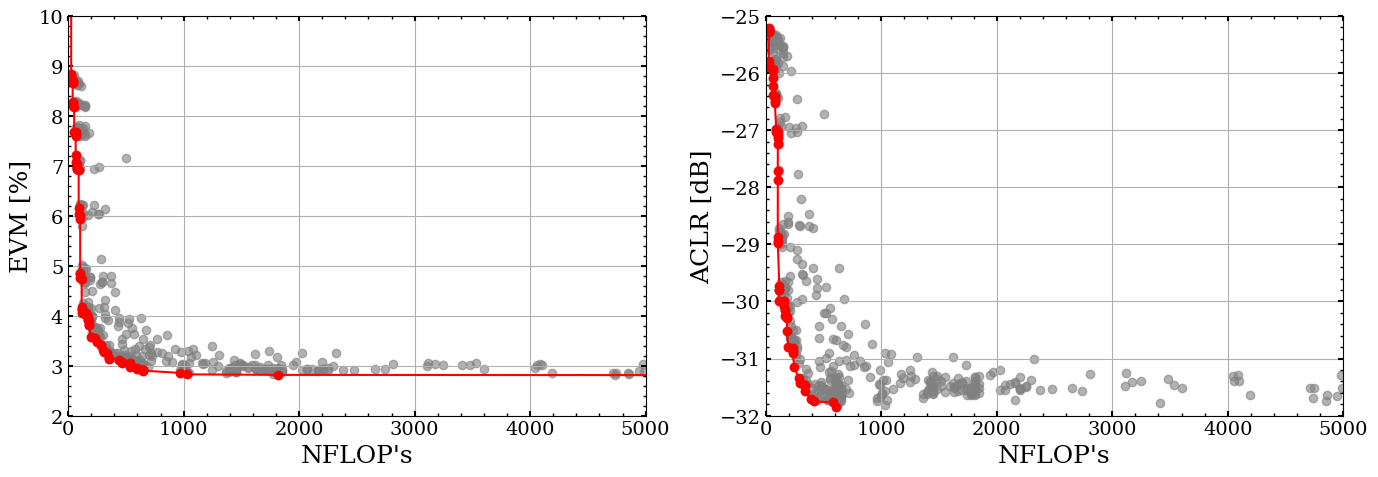

In [16]:
fig, axs = plt.subplots(1, 2, figsize = (14, 5))

# EVM vs NFLOPs
pareto_solutions_evm, pareto_trials_evm = get_pareto(study_EVM, study_NFLOPs, n_trials)

axs[0].scatter(study_NFLOPs, study_EVM, color = "gray", alpha = 0.6)
axs[0].plot(pareto_solutions_evm[:,1], pareto_solutions_evm[:,0], "-o", color = "r")

axs[0].set_xlim(0, 5e3)
axs[0].set_ylim(2., 10)
axs[0].set_xlabel("NFLOP's", fontsize = 18)
axs[0].set_ylabel("EVM [%]", fontsize = 18)

axs[0].minorticks_on()
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[0].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[0].grid()

# ACLR vs NFLOPs
pareto_solutions_aclr, pareto_trials_aclr = get_pareto(study_ACLR, study_NFLOPs, n_trials)

axs[1].scatter(study_NFLOPs, study_ACLR, color = "gray", alpha = 0.6)
axs[1].plot(pareto_solutions_aclr[:,1], pareto_solutions_aclr[:,0], "-o", color = "r")

axs[1].set_xlim(0, 5e3)
axs[1].set_ylim(-32, -25)
axs[1].set_xlabel("NFLOP's", fontsize = 18)
axs[1].set_ylabel("ACLR [dB]", fontsize = 18)

axs[1].minorticks_on()
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='minor',  width=1, direction = "in")
axs[1].tick_params(axis = 'both', top = "True", right = "True", which='major',  width=1.5, direction = "in")
axs[1].grid()

plt.tight_layout()
#plt.savefig(file_path + "\\Plots\\plot_pareto_EVM.png")

In [19]:
# Pareto Trials - EVM vs NFLOPs

for i, trial in enumerate(pareto_trials_evm):
    print(f"Trial {trial}: EVM = {study_EVM[trial]:.3f} %, NFLOPs = {study_NFLOPs[trial]}") 

Trial 17: EVM = 8.762 %, NFLOPs = 26.0
Trial 18: EVM = 3.480 %, NFLOPs = 247.0
Trial 21: EVM = 8.796 %, NFLOPs = 26.0
Trial 27: EVM = 3.420 %, NFLOPs = 286.0
Trial 30: EVM = 3.306 %, NFLOPs = 299.0
Trial 31: EVM = 8.833 %, NFLOPs = 26.0
Trial 32: EVM = 6.929 %, NFLOPs = 78.0
Trial 35: EVM = 3.949 %, NFLOPs = 169.0
Trial 44: EVM = 7.214 %, NFLOPs = 65.0
Trial 55: EVM = 3.047 %, NFLOPs = 533.0
Trial 62: EVM = 35.322 %, NFLOPs = 26.0
Trial 64: EVM = 6.032 %, NFLOPs = 91.0
Trial 68: EVM = 3.149 %, NFLOPs = 351.0
Trial 75: EVM = 8.249 %, NFLOPs = 39.0
Trial 80: EVM = 5.987 %, NFLOPs = 104.0
Trial 85: EVM = 8.652 %, NFLOPs = 39.0
Trial 95: EVM = 4.053 %, NFLOPs = 117.0
Trial 101: EVM = 2.811 %, NFLOPs = 5302.0
Trial 147: EVM = 5.986 %, NFLOPs = 104.0
Trial 160: EVM = 2.815 %, NFLOPs = 1813.0
Trial 163: EVM = 8.716 %, NFLOPs = 26.0
Trial 164: EVM = 8.740 %, NFLOPs = 26.0
Trial 165: EVM = 4.122 %, NFLOPs = 117.0
Trial 167: EVM = 7.082 %, NFLOPs = 65.0
Trial 173: EVM = 3.808 %, NFLOPs = 182.0
T

In [20]:
# Pareto Trials - ACLR vs NFLOPs

for i, trial in enumerate(pareto_trials_aclr):
    print(f"Trial {trial}: ACLR = {study_ACLR[trial]:.3f} dB, NFLOPs = {study_NFLOPs[trial]}") 

Trial 10: ACLR = -31.446 dB, NFLOPs = 325.0
Trial 17: ACLR = -25.257 dB, NFLOPs = 26.0
Trial 18: ACLR = -31.158 dB, NFLOPs = 247.0
Trial 21: ACLR = -25.267 dB, NFLOPs = 26.0
Trial 30: ACLR = -31.424 dB, NFLOPs = 299.0
Trial 31: ACLR = -25.215 dB, NFLOPs = 26.0
Trial 32: ACLR = -26.398 dB, NFLOPs = 78.0
Trial 35: ACLR = -30.144 dB, NFLOPs = 169.0
Trial 44: ACLR = -25.924 dB, NFLOPs = 65.0
Trial 62: ACLR = -25.849 dB, NFLOPs = 26.0
Trial 64: ACLR = -27.034 dB, NFLOPs = 91.0
Trial 80: ACLR = -27.038 dB, NFLOPs = 104.0
Trial 95: ACLR = -29.985 dB, NFLOPs = 117.0
Trial 163: ACLR = -25.277 dB, NFLOPs = 26.0
Trial 164: ACLR = -25.257 dB, NFLOPs = 26.0
Trial 165: ACLR = -29.806 dB, NFLOPs = 117.0
Trial 173: ACLR = -30.267 dB, NFLOPs = 182.0
Trial 176: ACLR = -29.986 dB, NFLOPs = 156.0
Trial 177: ACLR = -25.262 dB, NFLOPs = 26.0
Trial 178: ACLR = -27.081 dB, NFLOPs = 104.0
Trial 196: ACLR = -26.494 dB, NFLOPs = 78.0
Trial 199: ACLR = -27.145 dB, NFLOPs = 104.0
Trial 208: ACLR = -31.562 dB, NFLO